In [1]:
import os
import numpy as np
import tensorflow as tf
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_auc_score
import json

In [2]:
# Path to photos.json
json_path = r"C:\Users\ASUS\OneDrive\Desktop\Semester 3\Computer Vision\Yelp-Photos\Yelp Photos\yelp_photos\photos.json"

# Load the JSON file
with open(json_path, "r") as f:
    photos_data = [json.loads(line) for line in f]

# Create a dictionary to map photo_id to label
photo_id_to_label = {item["photo_id"]: item["label"] for item in photos_data}

# Data Preprocessing

In [3]:
# Path to the photos folder
dataset_path = r"C:\Users\ASUS\OneDrive\Desktop\Semester 3\Computer Vision\Yelp-Photos\Yelp Photos\yelp_photos\photos"

# Function to load and preprocess images
def load_and_preprocess_image(img_path, img_size=(64, 64)):
    try:
        # Read the image file
        img = tf.io.read_file(img_path)
        # Decode the image to a tensor
        img = tf.image.decode_image(img, channels=3, expand_animations=False)
        # Resize the image
        img = tf.image.resize(img, img_size)
        # Normalize pixel values to [0, 1]
        img = img / 255.0
        return img
    except:
        # Skip corrupted or unsupported files
        return None

# Load a subset of images (e.g., 10,000 images)
image_paths = [
    os.path.join(dataset_path, filename) 
    for filename in os.listdir(dataset_path) 
    if filename.lower().endswith(('.jpg', '.jpeg', '.png', '.gif', '.bmp'))
][:10000]  # Limit to 10,000 images

# Load images and labels
images = []
labels = []
for img_path in image_paths:
    photo_id = os.path.splitext(os.path.basename(img_path))[0]  # Extract photo_id from filename
    if photo_id in photo_id_to_label:  # Check if the photo_id exists in the JSON data
        img = load_and_preprocess_image(img_path)
        if img is not None:  # Only add valid images
            images.append(img)
            labels.append(photo_id_to_label[photo_id])

# Convert lists to numpy arrays
images = np.array(images)
labels = np.array(labels)

In [4]:
# Flatten images
n_samples = images.shape[0]
images_flattened = images.reshape(n_samples, -1)  # Shape: (n_samples, 64 * 64 * 3)

# Principal Component Analysis

In [5]:
from sklearn.decomposition import PCA

# Apply PCA to reduce dimensionality
pca = PCA(n_components=100)  # Choose the number of components based on explained variance
X_pca = pca.fit_transform(images_flattened)

# Split data again with reduced features
X_train, X_test, y_train, y_test = train_test_split(X_pca, labels, test_size=0.2, random_state=42)


# Hyperparameter Tuning

In [6]:
best_k = None
best_accuracy = 0

for k in [3, 5, 7, 9]:  # Try different values of k
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    accuracy = knn.score(X_test, y_test)  # Evaluate accuracy
    
    print(f"k={k}, Accuracy={accuracy:.4f}")
    
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_k = k

print(f"Best k: {best_k}, Best Accuracy: {best_accuracy:.4f}")


k=3, Accuracy=0.6808
k=5, Accuracy=0.7089
k=7, Accuracy=0.7264
k=9, Accuracy=0.7334
Best k: 9, Best Accuracy: 0.7334


# KNN Model Evaluation


Confusion Matrix:
[[ 20  73  59   0   6]
 [ 13 913 135   0   6]
 [  2 110 466   0  15]
 [  2  11  11   0   0]
 [  1  30  59   0  67]]

Classification Report:
              precision    recall  f1-score   support

       drink       0.53      0.13      0.20       158
        food       0.80      0.86      0.83      1067
      inside       0.64      0.79      0.70       593
        menu       0.00      0.00      0.00        24
     outside       0.71      0.43      0.53       157

    accuracy                           0.73      1999
   macro avg       0.54      0.44      0.45      1999
weighted avg       0.72      0.73      0.71      1999


Overall ROC-AUC Score: 0.7550


C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


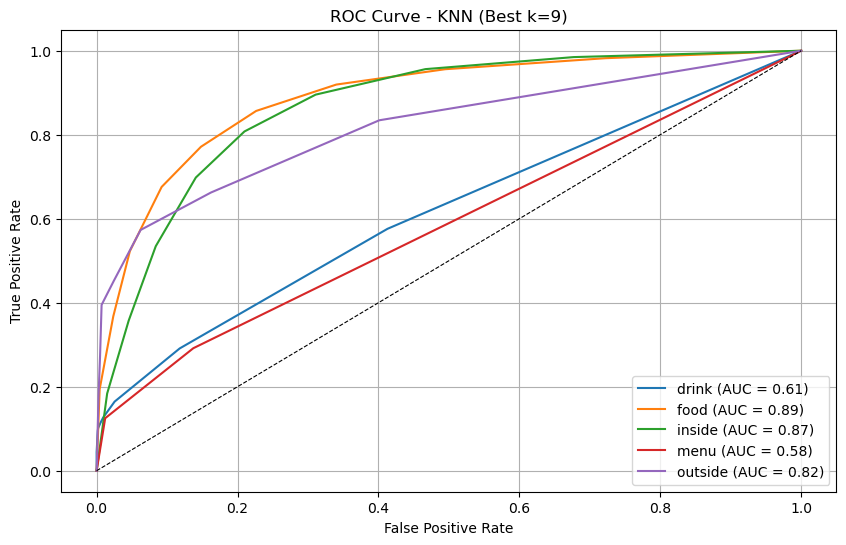

In [7]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize

# Final model with the best k value (k=9)
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train, y_train)

# Make predictions on the test data
y_test_pred = knn_final.predict(X_test)
y_test_proba = knn_final.predict_proba(X_test)

# Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_test_pred)
print(cm)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

# ROC-AUC Score (for multi-class classification)
y_test_binarized = label_binarize(y_test, classes=knn_final.classes_)
roc_auc = roc_auc_score(y_test_binarized, y_test_proba, average='macro', multi_class='ovr')
print(f"\nOverall ROC-AUC Score: {roc_auc:.4f}")

# Plot ROC curve for each class
plt.figure(figsize=(10, 6))
for i, label in enumerate(knn_final.classes_):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_test_proba[:, i])
    auc_score = roc_auc_score(y_test_binarized[:, i], y_test_proba[:, i])
    plt.plot(fpr, tpr, label=f"{label} (AUC = {auc_score:.2f})")

plt.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - KNN (Best k=9)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [9]:
pip install lime


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
# Round 2: Experiment with distance weighting
weighting_options = ['uniform', 'distance']
best_accuracy_weighting = 0
best_weighting = None

for weight in weighting_options:
    knn = KNeighborsClassifier(n_neighbors=best_k, metric=best_metric, weights=weight)
    knn.fit(X_train, y_train)
    accuracy = knn.score(X_test, y_test)
    print(f"Weighting: {weight}, Accuracy: {accuracy:.4f}")
    
    if accuracy > best_accuracy_weighting:
        best_accuracy_weighting = accuracy
        best_weighting = weight

print(f"Best Weighting: {best_weighting}, Best Accuracy: {best_accuracy_weighting:.4f}")


Weighting: uniform, Accuracy: 0.7334
Weighting: distance, Accuracy: 0.7364
Best Weighting: distance, Best Accuracy: 0.7364


# LIME for KNN

In [13]:
from lime.lime_tabular import LimeTabularExplainer
import numpy as np

# Create a LimeTabularExplainer instance
explainer = LimeTabularExplainer(
    training_data=X_train,  # The training data for the model
    training_labels=y_train,  # The labels for the training data
    mode="classification",  # Classification task
    feature_names=[f"Feature {i}" for i in range(X_train.shape[1])],  # Feature names (for explanation)
    class_names=np.unique(y_train),  # Class names for the labels
    discretize_continuous=True  # Optionally discretize continuous features
)

# Choose a sample from the test set to explain
image_idx = 10  # For example, explain the 10th image in the test set
test_sample = X_test[image_idx].reshape(1, -1)  # Reshape it to be a single row (batch size = 1)

# Get prediction for the test sample
predicted_class = knn_final.predict(test_sample)
print(f"Predicted class for test sample {image_idx}: {predicted_class[0]}")

# Use LIME to explain the prediction
explanation = explainer.explain_instance(test_sample[0], knn_final.predict_proba)

# Show the explanation
explanation.show_in_notebook()  # Displays the explanation in the notebook (if using Jupyter)


Predicted class for test sample 10: inside


# DNN

In [15]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_auc_score, recall_score
import numpy as np
import matplotlib.pyplot as plt

In [17]:
from sklearn.preprocessing import LabelEncoder

# Assuming X_pca and labels are already prepared from the previous code
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_pca, labels, test_size=0.2, random_state=42)

# Convert string labels to integer labels
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Convert integer labels to one-hot encoding
y_train = tf.keras.utils.to_categorical(y_train_encoded, num_classes=5)
y_test = tf.keras.utils.to_categorical(y_test_encoded, num_classes=5)

In [18]:
# Define the DNN model
model = Sequential()

# Input layer
model.add(Dense(512, input_shape=(X_train.shape[1],), activation='relu'))
model.add(Dropout(0.5))

# Hidden layers
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

# Output layer
model.add(Dense(5, activation='softmax'))

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# Print the model summary
model.summary()

C:\Users\ASUS\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 512)                 │          51,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 216,581 (846.02 KB)

 Trainable params: 216,581 (846.02 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=1)

Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.5104 - loss: 1.5738 - val_accuracy: 0.7117 - val_loss: 0.8923
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6709 - loss: 0.9810 - val_accuracy: 0.7261 - val_loss: 0.8271
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6996 - loss: 0.8739 - val_accuracy: 0.7248 - val_loss: 0.8289
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7330 - loss: 0.8127 - val_accuracy: 0.7323 - val_loss: 0.8222
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.7343 - loss: 0.7916 - val_accuracy: 0.7305 - val_loss: 0.8068
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7427 - loss: 0.7824 - val_accuracy: 0.7305 - val_loss: 0.7967
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7531 - loss: 0.7368 - val_accuracy: 0.7292 - val_loss: 0.7879
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7526 - loss: 0.7423 - val_accuracy:

# Evaluation

In [20]:
# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=1)
print(f'Test Accuracy: {test_acc:.4f}')

# Predict the classes
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred_classes)
print('Confusion Matrix:')
print(conf_matrix)

# Recall
recall = recall_score(y_true, y_pred_classes, average='macro')
print(f'Recall: {recall:.4f}')

# AUC
auc = roc_auc_score(y_test, y_pred, multi_class='ovr')
print(f'AUC: {auc:.4f}')

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7571 - loss: 0.8684
Test Accuracy: 0.7604
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Confusion Matrix:
[[ 34  73  41   0  10]
 [ 27 943  83   0  14]
 [ 12  83 459   0  39]
 [  0  14   8   1   1]
 [  2  18  54   0  83]]
Recall: 0.4887
AUC: 0.8445


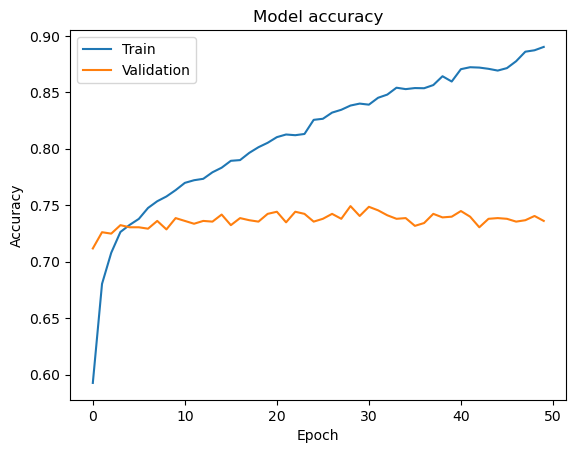

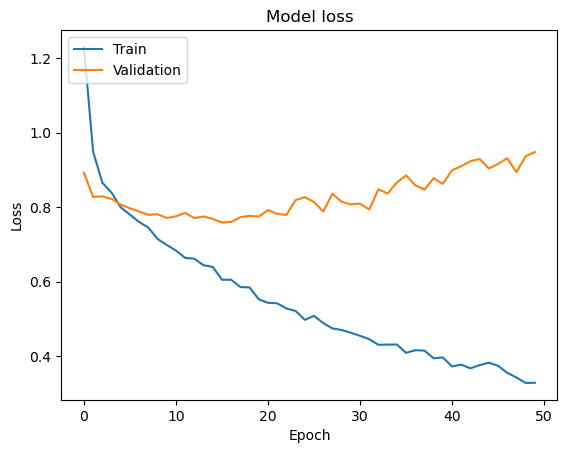

In [21]:
# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()